# Churn Predictor — Análisis Exploratorio de Datos (EDA)

## Contexto del Negocio

El **churn** (abandono de clientes) es uno de los problemas más costosos para las empresas de telecomunicaciones. 
Retener un cliente existente cuesta entre **5x y 7x menos** que adquirir uno nuevo.

Este notebook analiza el dataset de Telco Customer Churn con el objetivo de:
- Entender el perfil de los clientes que abandonan el servicio
- Identificar las variables con mayor poder predictivo
- Generar hipótesis que guíen el modelado en la siguiente fase

**Dataset:** IBM Telco Customer Churn — 7,043 clientes, 21 variables  
**Variable objetivo:** `Churn` (Yes/No)

## 1. Importación de Librerías

In [1]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)

# Suprimir warnings innecesarios
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente")

Librerías importadas correctamente


## 2. Carga de Datos

In [2]:
from pathlib import Path

DATA_PATH = Path().resolve().parent / 'data' / 'raw' / 'WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(DATA_PATH)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


> **Observación:** El dataset contiene variables demográficas (`gender`, `SeniorCitizen`, `Partner`), 
> variables de servicios contratados (`PhoneService`, `InternetService`, `StreamingTV`), 
> variables contractuales (`Contract`, `PaymentMethod`, `MonthlyCharges`) y la variable objetivo `Churn`. 
> A primera vista, `Contract` y `tenure` parecen candidatos fuertes para predecir abandono — 
> un cliente mes a mes con poco tiempo en la empresa tiene menos compromiso con el servicio.

## 3. Inspección General del Dataset

In [3]:
print(f"Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nValores nulos por columna:\n{df.isnull().sum()}")

Dimensiones del dataset: 7,043 filas x 21 columnas

Tipos de datos:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Valores nulos por columna:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV     

> **Observación:** El dataset tiene 7,043 registros y 21 columnas sin valores nulos aparentes. 
> Sin embargo, `TotalCharges` figura como `object` cuando debería ser `float64` — 
> esto indica que contiene espacios en blanco (`" "`) que pandas interpretó como texto en lugar de números. 
> Esto se corregirá en la fase de limpieza. `customerID` no aporta valor predictivo y será eliminada.

## 4. Estadísticas Descriptivas

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.00,NaN,NaN,NaN,0.16,0.37,0.00,0.00,0.00,0.00,1.00
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.00,NaN,NaN,NaN,32.37,24.56,0.00,9.00,29.00,55.00,72.00
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


> **Observación:** Se confirman varios hallazgos clave:
> - `TotalCharges` tiene 11 registros con valor vacío `" "` — confirma el problema de tipo `object`. Requiere conversión y manejo de esos 11 casos.
> - `Contract` tiene como valor más frecuente `Month-to-month` con 3,875 clientes (55% del total) — el segmento de mayor riesgo de churn.
> - `tenure` va de 0 a 72 meses con mediana de 29 — la base de clientes está distribuida entre nuevos y leales.
> - `Churn = No` aparece 5,174 veces de 7,043 — el dataset está desbalanceado (~73% No, ~27% Yes). Esto se abordará en el modelado.
> - `customerID` tiene 7,043 valores únicos — confirma que no aporta valor predictivo y debe eliminarse.

## 5. Limpieza de Datos

In [5]:
# Eliminar customerID — no aporta valor predictivo
df = df.drop(columns=['customerID'])

# Convertir TotalCharges a numérico — los espacios en blanco se convierten a NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Verificar cuántos NaN generó la conversión
print(f"NaN en TotalCharges después de conversión: {df['TotalCharges'].isnull().sum()}")

NaN en TotalCharges después de conversión: 11


### 5.1 Análisis de los 11 registros con TotalCharges vacío

Antes de decidir entre imputar o eliminar, inspeccionamos los registros problemáticos
para entender si los datos faltan por error de captura o por una razón de negocio válida.

In [6]:
# Recargar el dataset original para inspeccionar antes de cualquier transformación
df_raw = pd.read_csv(DATA_PATH)

# Identificar los 11 registros con TotalCharges vacío
mask = df_raw['TotalCharges'].str.strip() == ''
registros_vacios = df_raw[mask][['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
print(f"Registros con TotalCharges vacío: {mask.sum()}")
registros_vacios

Registros con TotalCharges vacío: 11


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


### Decisión: Eliminar vs Imputar

La inspección confirma que los 11 registros con `TotalCharges` vacío tienen `tenure = 0` 
y `Churn = No` en todos los casos. Esto no es un error de captura — son clientes que 
se registraron pero no completaron su primer mes de servicio.

**Opciones evaluadas:**
- **Imputar con 0:** Lógico dado que `tenure = 0`, pero introduciría un perfil atípico 
  sin historial real que podría distorsionar las distribuciones.
- **Imputar con media/mediana:** Incorrecto — estaríamos inventando un historial 
  financiero que no existe.
- **Eliminar:** Perdemos 11 registros de 7,043 (0.15%). Impacto nulo en el modelo.

**Decisión:** Eliminar. Los datos no faltan por error sino por una razón de negocio válida.

### 5.2 Limpieza Final

In [7]:
# Eliminar los 11 registros con TotalCharges nulo
df = df.dropna(subset=['TotalCharges'])

# Convertir Churn a binario (0/1)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Verificar resultado
print(f"Dimensiones después de limpieza: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"\nTipo de TotalCharges: {df['TotalCharges'].dtype}")
print(f"Valores únicos de Churn: {df['Churn'].unique()}")

Dimensiones después de limpieza: 7,032 filas x 20 columnas

Tipo de TotalCharges: float64
Valores únicos de Churn: [0 1]


## 6. Análisis de la Variable Objetivo — Churn

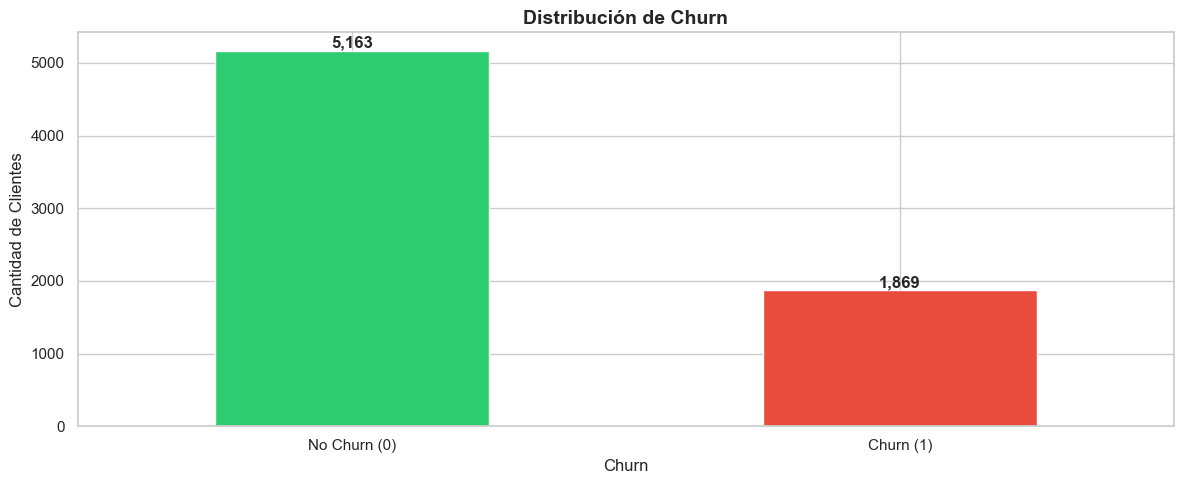

Clientes que NO hicieron churn: 5,163 (73.4%)
Clientes que SÍ hicieron churn: 1,869 (26.6%)
Ratio de desbalance: 2.8:1


In [8]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

ax = churn_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='white')
ax.set_title('Distribución de Churn', fontsize=14, fontweight='bold')
ax.set_ylabel('Cantidad de Clientes')
ax.set_xticklabels(['No Churn (0)', 'Churn (1)'], rotation=0)

for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Clientes que NO hicieron churn: {churn_counts[0]:,} ({churn_pct[0]:.1f}%)")
print(f"Clientes que SÍ hicieron churn: {churn_counts[1]:,} ({churn_pct[1]:.1f}%)")
print(f"Ratio de desbalance: {churn_counts[0]/churn_counts[1]:.1f}:1")

> **Observación:** El 26.6% de los clientes hizo churn — una tasa significativamente alta 
> para el sector de telecomunicaciones. El desbalance de 2.8:1 será considerado en el 
> modelado usando `class_weight` o ajuste de threshold para evitar que el modelo ignore 
> la clase minoritaria. En términos de negocio, aproximadamente 1 de cada 4 clientes abandona el servicio 
> — esto justifica ampliamente la inversión en un modelo predictivo de detección temprana.

## 7. Análisis de Variables Numéricas

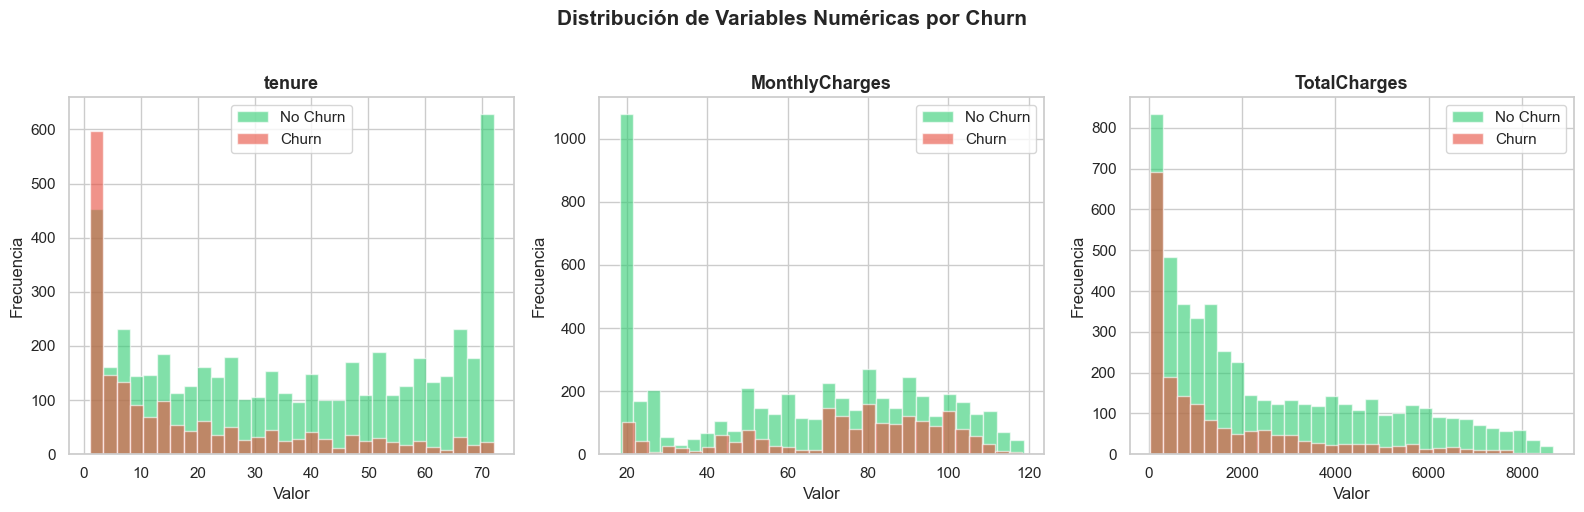

In [9]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(num_cols):
    axes[i].hist(df[df['Churn'] == 0][col], bins=30, alpha=0.6, 
                 color='#2ecc71', label='No Churn')
    axes[i].hist(df[df['Churn'] == 1][col], bins=30, alpha=0.6, 
                 color='#e74c3c', label='Churn')
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

plt.suptitle('Distribución de Variables Numéricas por Churn', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

> **Observación:** Las tres variables numéricas muestran patrones distintos entre clientes 
> que hacen churn y los que no:
> - **tenure:** Los clientes que abandonan se concentran fuertemente en los primeros meses. 
>   A mayor antigüedad, menor probabilidad de churn — los clientes leales tienden a quedarse.
> - **MonthlyCharges:** El churn es más frecuente en clientes con cargos mensuales altos. 
>   Clientes con planes más costosos tienen mayor propensión a buscar alternativas.
> - **TotalCharges:** Sigue el mismo patrón que tenure — valores bajos indican clientes 
>   nuevos con mayor riesgo de abandono.
> 
> Estas tres variables serán features de alto poder predictivo en el modelo.

## 8. Análisis de Variables Categóricas

In [10]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
            'PhoneService', 'InternetService', 'Contract', 
            'PaperlessBilling', 'PaymentMethod']

resultados = []
for col in cat_cols:
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    for categoria, tasa in churn_rate.items():
        resultados.append({'Variable': col, 'Categoría': categoria, 'Churn Rate (%)': round(tasa, 1)})

tabla = pd.DataFrame(resultados)
tabla.sort_values(['Variable', 'Churn Rate (%)'], ascending=[True, False])

,Variable,Categoría,Churn Rate (%)
13,Contract,Month-to-month,42.70
14,Contract,One year,11.30
15,Contract,Two year,2.80
6,Dependents,No,31.30
7,Dependents,Yes,15.50
11,InternetService,Fiber optic,41.90
10,InternetService,DSL,19.00
12,InternetService,No,7.40
17,PaperlessBilling,Yes,33.60
16,PaperlessBilling,No,16.40


> **Observación:** La tabla revela los factores categóricos con mayor impacto en churn:
> - **Contract:** La variable más poderosa — clientes mes a mes tienen 42.7% de churn 
>   vs apenas 2.8% en contratos de dos años. Comprometer al cliente en un contrato largo 
>   es la estrategia de retención más efectiva.
> - **PaymentMethod:** Clientes que pagan con cheque electrónico tienen 45.3% de churn — 
>   casi el doble que los métodos automáticos. Los pagos manuales sugieren menor compromiso.
> - **InternetService:** Fiber optic tiene 41.9% de churn — posiblemente por el alto costo 
>   del servicio o insatisfacción con la calidad.
> - **gender:** Diferencia mínima (27% vs 26.2%) — no será una variable relevante para el modelo.
> - **SeniorCitizen:** Los clientes mayores tienen 41.7% de churn vs 23.7% — 
>   un segmento vulnerable que merece atención especial.

## 9. Análisis de Correlación

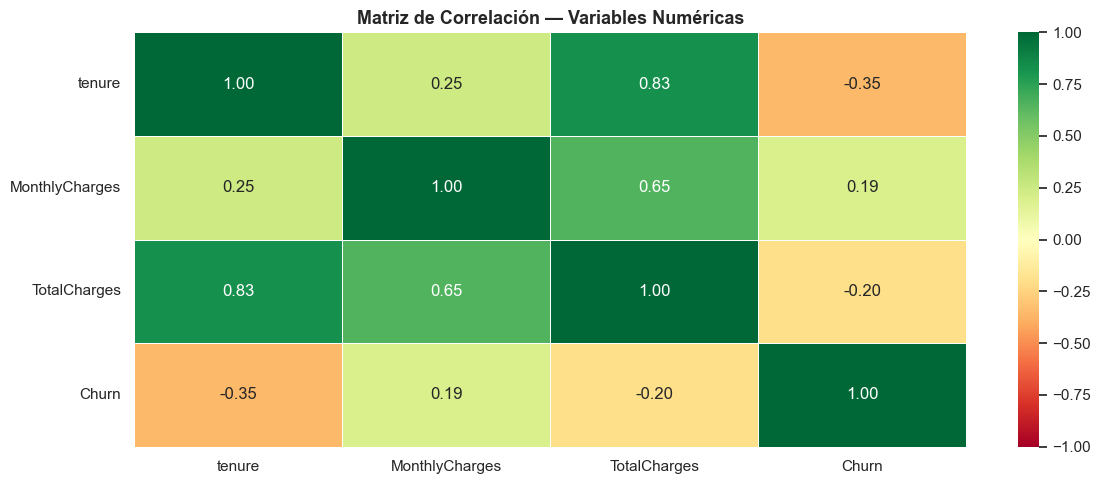

In [11]:
corr_matrix = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación — Variables Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Observación:** La matriz de correlación revela tres hallazgos clave:
> - **tenure vs Churn (-0.35):** Correlación negativa — a mayor antigüedad, menor churn. 
>   Confirma que los primeros meses son el período crítico de retención.
> - **MonthlyCharges vs Churn (0.19):** Correlación positiva leve — clientes con cargos 
>   más altos tienden a abandonar más, posiblemente por percibir menor valor en el servicio.
> - **tenure vs TotalCharges (0.83):** Correlación muy alta — son variables redundantes 
>   ya que TotalCharges es en gran parte una función acumulada de tenure. El modelo podría 
>   beneficiarse de mantener ambas o evaluar si una aporta información adicional a la otra.

## 11. Conclusiones del EDA

### Hallazgos Clave

**Variables más relevantes para predecir churn:**
- `Contract` — la variable más poderosa: clientes mes a mes tienen 42.7% de churn vs 2.8% en contratos de dos años.
- `tenure` — correlación negativa de -0.35 con churn: los primeros meses son el período crítico de retención.
- `PaymentMethod` — clientes con cheque electrónico tienen 45.3% de churn vs ~15% en métodos automáticos.
- `InternetService` — Fiber optic tiene 41.9% de churn, posiblemente por alto costo o insatisfacción.
- `MonthlyCharges` — correlación positiva con churn: planes más costosos tienen mayor abandono.

**Variables con poco poder predictivo:**
- `gender` — diferencia mínima entre géneros (27% vs 26.2%). Probablemente no aporte valor al modelo.
- `PhoneService` — churn rate similar entre clientes con y sin servicio telefónico (26.7% vs 25%).

**Consideraciones para el modelado:**
- Desbalance de clases 2.8:1 — se usará `class_weight='balanced'` o ajuste de threshold.
- `TotalCharges` y `tenure` tienen correlación alta (0.83) — evaluar multicolinealidad durante el modelado.
- Variables categóricas requieren encoding — se usará `OneHotEncoder` dentro de un Pipeline de sklearn.

### Hipótesis para el Modelado
1. `Contract`, `tenure` y `PaymentMethod` serán las features de mayor peso en SHAP.
2. Un cliente con contrato mes a mes, tenure bajo y cheque electrónico tiene el perfil de mayor riesgo.
3. El modelo deberá optimizarse para **Recall** — es más costoso no detectar un cliente en riesgo que intervenir innecesariamente.

## 12. Guardar Dataset Limpio

In [12]:
from pathlib import Path

PROCESSED_PATH = Path().resolve().parent / 'data' / 'processed' / 'telco_churn_clean.parquet'
df.to_parquet(PROCESSED_PATH, index=False)

print(f"Dataset guardado en: data/processed/telco_churn_clean.parquet")
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")

Dataset guardado en: data/processed/telco_churn_clean.parquet
Dimensiones: 7,032 filas x 20 columnas
